# Phishing Website Detection — A Critical Reproduction Study

**Course:** Data Science in Cyber — Final Project
**Domain:** Phishing Detection


---

### Source under evaluation

> **shreyagopal — *Phishing Website Detection by Machine Learning Techniques***
> GitHub: https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques
> Write-up: *Phishing Website Detection by Machine Learning Techniques* (project README + accompanying Medium-style report)

The tutorial extracts 17 features from URLs, builds a **balanced 10,000-row dataset**
(5,000 phishing URLs from PhishTank, 5,000 legitimate URLs from a benign-URL corpus),
trains six classifiers, and reports **test accuracy in the low–mid 0.80s, with XGBoost
the best model (≈0.86)**. It concludes that the approach is an effective phishing
detector.

### What this notebook does

This is **not** a re-run of the tutorial. We *reproduce* the pipeline and then
*critically test whether the author's claims are supported by the data and experiments*.
Concretely we ask:

1. Are the reported accuracies reproducible, and are they the *right* metric?
2. Do the features measure phishing, or do they measure **which source a URL came from**
   (selection bias / leakage)?
3. Is the code reproducible today (the feature extractor depends on **Alexa rank**,
   discontinued in 2022, and live **WHOIS** lookups)?
4. What happens to the headline numbers under **realistic phishing prevalence** rather
   than an artificial 50/50 split?

The notebook is organised as: Data Loading → EDA → Feature Engineering → Model Training
→ Evaluation → Error Analysis → Critical Synthesis.

## 0. Setup and configuration

We fix a single global random seed and centralise configuration so every result in the
notebook is deterministic and reproducible.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# ---- Global configuration ---------------------------------------------------
RANDOM_STATE = 42          # single seed used everywhere for reproducibility
TEST_SIZE = 0.20           # hold-out fraction
CV_FOLDS = 5               # stratified CV folds
BETA = 2.0                 # F-beta beta: beta>1 weights RECALL over precision
DATA_PATH = Path("data/urldata.csv")
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUT_DIR / "figures"; FIG_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# Containers populated through the notebook and exported at the end for the report.
RESULTS = {}        # model_name -> metric dict
KEY_FINDINGS = {}   # scalar findings referenced by the PDF report
print("Setup complete. Seed =", RANDOM_STATE)

Setup complete. Seed = 42


### Reusable helpers

We define a handful of small, focused functions up front so the training and evaluation
sections stay readable and free of duplicated code.

In [2]:
def save_fig(fig, name):
    '''Persist a figure to outputs/figures so the PDF report can embed it.'''
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=130)


def positive_scores(model, X):
    '''Return a continuous score for the positive class (phishing=1).

    Uses predict_proba when available, otherwise the SVM decision function.
    AUC is rank-based, so an un-normalised decision score is fine.
    '''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def cramers_v(x, y):
    '''Bias-corrected Cramer's V association between two categorical series.'''
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0


def evaluate(name, model, X_te, y_te, store=True):
    '''Compute the full metric suite for a fitted model on the test set.'''
    y_pred = model.predict(X_te)
    y_score = positive_scores(model, X_te)
    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        f"f{int(BETA)}": fbeta_score(y_te, y_pred, beta=BETA),
        "mcc": matthews_corrcoef(y_te, y_pred),
        "roc_auc": roc_auc_score(y_te, y_score),
        "pr_auc": average_precision_score(y_te, y_score),
    }
    if store:
        RESULTS[name] = metrics
    return metrics, y_pred, y_score


def precision_at_prevalence(tpr, fpr, prevalence):
    '''Bayes-corrected precision (PPV) if the true phishing base rate were `prevalence`.

    The test set is 50/50 by construction; this re-projects the SAME confusion-matrix
    rates onto a realistic base rate to expose how precision degrades in deployment.
    '''
    tp = prevalence * tpr
    fp = (1 - prevalence) * fpr
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan

## 1. Data loading and inspection



In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
KEY_FINDINGS["n_rows"], KEY_FINDINGS["n_cols"] = df.shape
df.head()

Dataset shape: (10000, 18)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [4]:
# Feature types: one identifier (Domain), one discrete count (URL_Depth), the rest binary.
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "example": df.iloc[0],
})
info

,dtype,n_unique,n_missing,example
Domain,str,3553,0,graphicriver.net
Have_IP,int64,2,0,0
Have_At,int64,2,0,0
URL_Length,int64,2,0,1
URL_Depth,int64,18,0,1
Redirection,int64,2,0,0
https_Domain,int64,2,0,0
TinyURL,int64,2,0,0
Prefix/Suffix,int64,2,0,0
DNS_Record,int64,2,0,0


**Reading the table.**

* **Size & types.** 10,000 rows × 18 columns. Apart from `Domain` (a string identifier)
  and `URL_Depth` (a small integer count), every column is **binary {0, 1}**. The author
  has already *binarised* most signals during feature extraction.
* **Index / column names.** The index is a meaningless `RangeIndex` and the column names
  are self-describing — this is fine. `Domain` is a **row identifier**, not a feature: it
  must be excluded from modelling (otherwise the model memorises domains) but it is
  invaluable for the leakage check in §2.
* **Missing values.** None are encoded as `NaN`. This is itself worth flagging: the
  WHOIS-derived features (`Domain_Age`, `Domain_End`) *cannot* be known for every domain
  in practice, so "no missing values" most likely means **failures were silently coerced
  to 0** during extraction — a hidden preprocessing step (revisited in §7).

In [5]:
# Missing values, explicit duplicates, and constant / near-constant features.
print("Missing values total:", int(df.isna().sum().sum()))
print("Fully duplicated rows:", int(df.duplicated().sum()))

feature_cols_all = [c for c in df.columns if c not in ("Domain", "Label")]
dup_feat = df.duplicated(subset=feature_cols_all).sum()
print(f"Rows that are duplicates on the {len(feature_cols_all)} features (ignoring Domain):", int(dup_feat))

# Near-zero-variance detection: dominant value share per feature.
dominant_share = {c: df[c].value_counts(normalize=True).iloc[0] for c in feature_cols_all}
nzv = pd.Series(dominant_share).sort_values(ascending=False)
print("\nTop features by dominant-value share (1.0 == constant):")
print(nzv.head(6).round(4))
KEY_FINDINGS["dup_feature_rows"] = int(dup_feat)

Missing values total: 0
Fully duplicated rows: 5626
Rows that are duplicates on the 16 features (ignoring Domain): 9229

Top features by dominant-value share (1.0 == constant):
https_Domain    0.9998
Right_Click     0.9993
Have_IP         0.9945
Redirection     0.9865
Have_At         0.9774
Mouse_Over      0.9334
dtype: float64


**Temporal analysis.** The dataset has **no timestamp column**, so a direct temporal
analysis is impossible — yet phishing is an intensely *time-dependent* phenomenon
(campaigns appear and vanish within days). Two consequences follow:

1. The train/test split cannot be time-ordered, so the evaluation implicitly assumes
   phishing looks the same in the future as in the (≈2020) snapshot — it ignores
   **concept drift**. A deployed detector trained here would decay.
2. Time leaks *indirectly* through `Domain_Age`, `Web_Traffic`, and `Domain_End`, which
   encode how established a domain was **at extraction time**. These are not stable URL
   properties; re-extracting them later yields different values.

**Single-value / redundant features.** `https_Domain` and `Right_Click` are (near-)
constant — they carry essentially no information yet are shipped as model inputs. We
quantify and remove these in §3.

## 2. Exploratory Data Analysis (EDA)



### 2.1 Class balance and prevalence — the central caveat

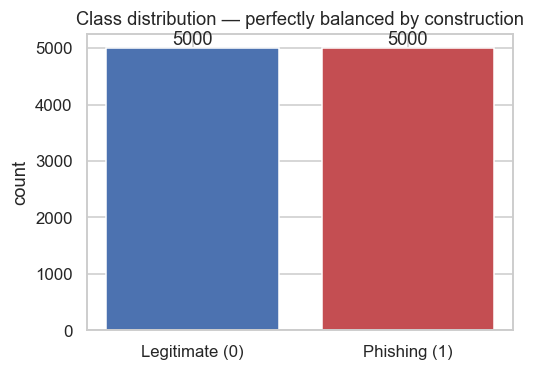

Prevalence of phishing in dataset: 50.0%


In [6]:
counts = df["Label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Legitimate (0)", "Phishing (1)"], counts.values, color=["#4c72b0", "#c44e52"])
ax.set_title("Class distribution — perfectly balanced by construction")
ax.set_ylabel("count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center")
save_fig(fig, "class_balance"); plt.show()
print("Prevalence of phishing in dataset: %.1f%%" % (100 * df["Label"].mean()))

The classes are a **perfect 50/50 split** — but this is an *artefact of dataset
construction*, not reality. Industry telemetry puts phishing at a **small fraction of a
percent** of web traffic. A 50/50 training/evaluation set means:

* **Accuracy is inflated and misleading.** A coin-flip already scores 50%; the
  "impressive" 86% must be read against that, and against MCC/F-β which are robust to
  balance.
* **Deployment precision will collapse.** With a tiny true base rate, even a low false-
  positive rate produces overwhelmingly more false alarms than true catches. We quantify
  this in §5.4 — it is the single most important critique of the source.

The tutorial **does not address** this: it neither resamples toward realistic prevalence
nor reports prevalence-robust metrics.

### 2.2 Feature distributions and group-by separation

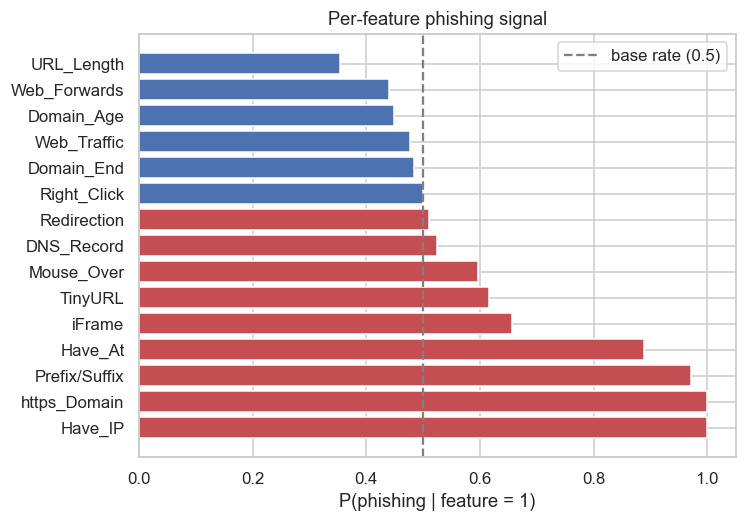

,P(phish|feat=1),share_with_feat=1
Have_IP,1.000,0.006
https_Domain,1.000,0.000
Prefix/Suffix,0.972,0.093
Have_At,0.889,0.023
iFrame,0.656,0.091
TinyURL,0.616,0.090
Mouse_Over,0.596,0.067
DNS_Record,0.524,0.101
Redirection,0.511,0.014
Right_Click,0.500,0.999


In [7]:
# Per-feature phishing rate: P(phishing | feature = 1) for each binary flag.
binary_feats = [c for c in feature_cols_all if df[c].nunique() == 2]
rate = pd.DataFrame({
    "P(phish|feat=1)": [df.loc[df[c] == 1, "Label"].mean() for c in binary_feats],
    "share_with_feat=1": [df[c].mean() for c in binary_feats],
}, index=binary_feats).sort_values("P(phish|feat=1)", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c44e52" if v > 0.5 else "#4c72b0" for v in rate["P(phish|feat=1)"]]
ax.barh(rate.index, rate["P(phish|feat=1)"], color=colors)
ax.axvline(0.5, ls="--", c="grey", label="base rate (0.5)")
ax.set_xlabel("P(phishing | feature = 1)"); ax.set_title("Per-feature phishing signal")
ax.legend(); save_fig(fig, "feature_signal"); plt.show()
rate.round(3)

In [8]:
# Group-by: mean of every feature per class -> compact separation view.
group_means = df.drop(columns=["Domain"]).groupby("Label").mean().T
group_means["abs_gap"] = (group_means[1] - group_means[0]).abs()
group_means.sort_values("abs_gap", ascending=False).round(3)

Label,0,1,abs_gap
URL_Depth,3.327,2.817,0.510
URL_Length,1.000,0.547,0.453
Prefix/Suffix,0.005,0.181,0.176
Domain_Age,0.456,0.372,0.084
Web_Traffic,0.885,0.806,0.079
iFrame,0.063,0.119,0.057
Domain_End,0.837,0.783,0.054
TinyURL,0.069,0.111,0.042
Have_At,0.005,0.040,0.035
Mouse_Over,0.054,0.079,0.026


**The smoking gun — `URL_Length`.** Every legitimate URL has `URL_Length = 1` (mean
1.000) while only ~55% of phishing URLs do. `URL_Length = 1` means *"URL longer than 54
characters."* The legitimate corpus was sampled as **full deep links** (all long), while
PhishTank entries are frequently bare domains (short). So this feature largely encodes
**which file the row came from, not whether it is phishing** — a textbook case of
**selection bias / source leakage**. We verify the all-ones property explicitly:

In [9]:
legit_urllen = df.loc[df.Label == 0, "URL_Length"]
print("Legit rows with URL_Length==1: %.1f%%" % (100 * legit_urllen.mean()))
print("Phish rows with URL_Length==1: %.1f%%" % (100 * df.loc[df.Label == 1, 'URL_Length'].mean()))
KEY_FINDINGS["legit_urllen_is_1_pct"] = round(100 * legit_urllen.mean(), 1)

Legit rows with URL_Length==1: 100.0%
Phish rows with URL_Length==1: 54.7%


### 2.3 Outlier analysis

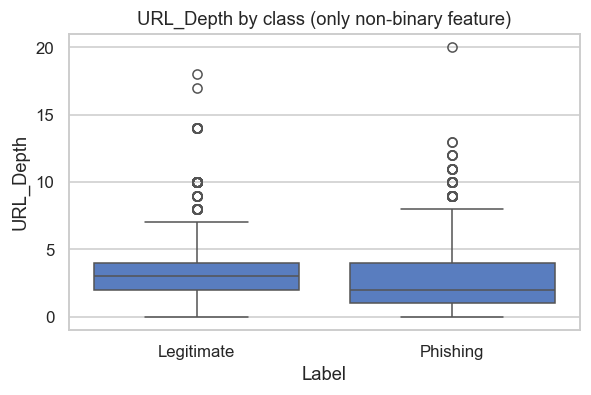

URL_Depth IQR outlier threshold (>7.0): 357 rows


In [10]:
# Binary features cannot contain outliers in the usual sense; only URL_Depth is a count.
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="Label", y="URL_Depth", ax=ax)
ax.set_xticklabels(["Legitimate", "Phishing"])
ax.set_title("URL_Depth by class (only non-binary feature)")
save_fig(fig, "urldepth_box"); plt.show()

q1, q3 = df["URL_Depth"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"URL_Depth IQR outlier threshold (>{upper:.1f}): "
      f"{int((df['URL_Depth'] > upper).sum())} rows")

Outlier analysis is only meaningful for `URL_Depth` — the binary flags have no notion of
an outlier. A handful of very deep URLs exist but they are legitimate structural depth
(long paths), not data errors, so we **keep** them. This aligns with world knowledge:
deep paths are normal for large, content-rich sites.

### 2.4 Correlation analysis — choosing the right coefficient

The choice of correlation measure must be justified by the data type:

* **Pearson** assumes continuous, linear, roughly-normal variables. Our features are
  binary/ordinal, so Pearson is **not appropriate** as a primary tool (for two binary
  variables Pearson's r degenerates to the **φ coefficient**, which is defensible, but
  Pearson across binary+count mixes scales).
* **Spearman** (rank correlation) is robust to non-normality and monotonic relations and
  behaves sensibly on ordinal data — our **primary** choice for the feature–feature and
  feature–target screen.
* **Kendall's τ** agrees with Spearman here and is preferable for small samples; with
  n = 10,000 the two coincide, so we report Spearman.
* Because association between *categorical* variables is not fully captured by rank
  correlation, we **complement** Spearman with **Cramér's V** (categorical association)
  and **mutual information** (captures non-monotonic dependence). Using three lenses
  guards against any single measure's blind spot.

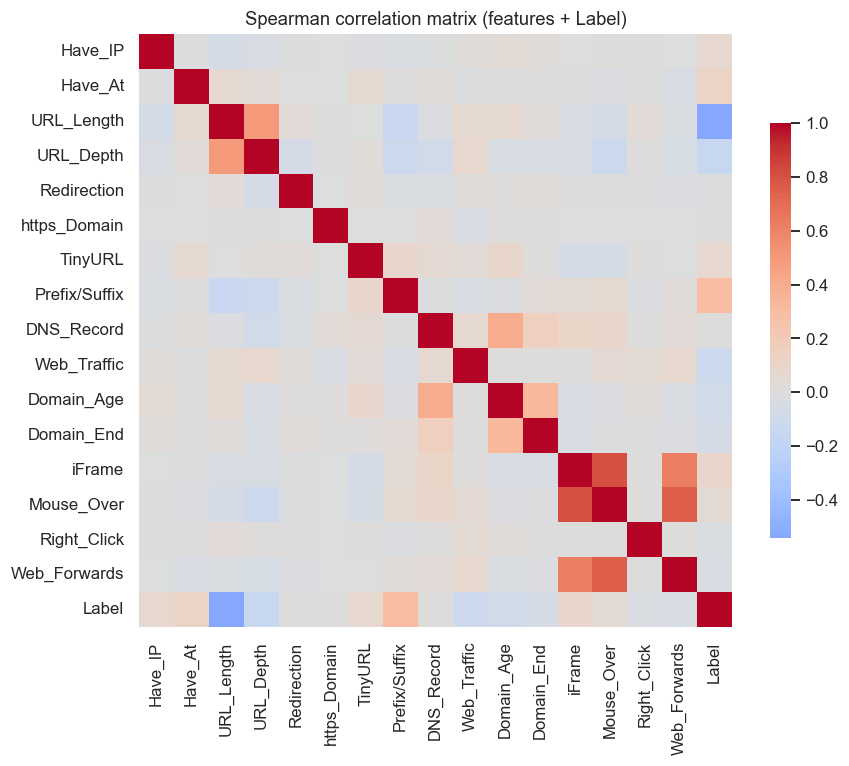

Spearman correlation with Label (|r| desc):
URL_Length      -0.541
Prefix/Suffix    0.303
URL_Depth       -0.150
Have_At          0.118
Web_Traffic     -0.109
iFrame           0.098
Domain_Age      -0.085
Have_IP          0.074
TinyURL          0.073
Domain_End      -0.069
Mouse_Over       0.051
Web_Forwards    -0.041
Right_Click     -0.026
DNS_Record       0.016
https_Domain     0.014
Redirection      0.003
Name: Label, dtype: float64


In [11]:
model_feats = [c for c in feature_cols_all]  # exclude identifier/target only
spearman = df[model_feats + ["Label"]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(spearman, cmap="coolwarm", center=0, annot=False, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation matrix (features + Label)")
save_fig(fig, "spearman_heatmap"); plt.show()

# Spearman vs target, ranked.
corr_target = spearman["Label"].drop("Label").sort_values(key=np.abs, ascending=False)
print("Spearman correlation with Label (|r| desc):")
print(corr_target.round(3))

In [12]:
# Mutual information and Cramers V give complementary, non-linear / categorical views.
X_all = df[model_feats]
mi = pd.Series(
    mutual_info_classif(X_all, df["Label"], discrete_features=True, random_state=RANDOM_STATE),
    index=model_feats,
).sort_values(ascending=False)

cv = pd.Series({c: cramers_v(df[c], df["Label"]) for c in model_feats}).sort_values(ascending=False)

assoc = pd.DataFrame({
    "spearman_abs": corr_target.abs(),
    "mutual_info": mi,
    "cramers_v": cv,
}).sort_values("mutual_info", ascending=False)
assoc.round(3)

,spearman_abs,mutual_info,cramers_v
URL_Length,0.541,0.191,0.541
URL_Depth,0.150,0.073,0.350
Prefix/Suffix,0.303,0.057,0.302
Have_At,0.118,0.008,0.117
Web_Traffic,0.109,0.006,0.108
iFrame,0.098,0.005,0.098
Have_IP,0.074,0.004,0.072
Domain_Age,0.085,0.004,0.084
TinyURL,0.073,0.003,0.072
Domain_End,0.069,0.002,0.068


**Statistical vs practical significance.** With n = 10,000, almost *any* non-zero
correlation is "statistically significant" — significance is cheap. What matters is
**effect size**: only `URL_Length`, `Prefix/Suffix`, and `URL_Depth` show *practically*
meaningful association; most flags have |Spearman| < 0.1 and mutual information near zero.
The detector is effectively a **two-or-three feature model wearing a 16-feature coat** —
and the strongest feature (`URL_Length`) is the biased one. That is a critical finding:
the apparent accuracy rests on a feature that reflects data provenance.

**Redundancy.** Off-diagonal blocks in the heatmap (and the duplicated-feature-row count
from §1) reveal redundancy. We detect it via (a) the correlation matrix, (b) mutual
information ≈ 0 features, and (c) near-zero-variance flags, then remove the offenders in
§3. The principled tools are correlation/MI screening and, for linear models, variance-
inflation; tree ensembles tolerate redundancy but it still inflates apparent feature
importance and hurts interpretability.

### 2.5 Feature-space degeneracy and the accuracy *ceiling*

The duplicated-feature-row count from §1 hinted at something deeper. The 17 features are
so coarse (mostly binary) that the 10,000 URLs collapse into a tiny number of distinct
feature vectors. We measure how much information the representation actually retains — and
derive the **theoretical best accuracy any classifier can reach** on it.

In [13]:
# How many genuinely distinct feature vectors exist, and how many are 'ambiguous'
# (the identical vector occurs with BOTH labels -> irreducible / Bayes error).
group_label = df.groupby(feature_cols_all)["Label"]
n_unique_vectors = df[feature_cols_all].drop_duplicates().shape[0]
ambiguous_rows = group_label.transform("nunique").gt(1).sum()
# Majority-vote (Bayes-optimal) accuracy: best possible if we just predict the
# most common label within each identical feature vector. agg gives ONE majority
# count per distinct vector; summing those over all vectors / N is the ceiling.
ceiling = group_label.agg(lambda s: s.value_counts().iloc[0]).sum() / len(df)

print(f"Distinct feature vectors:      {n_unique_vectors} of {len(df)}")
print(f"Rows that are ambiguous:       {int(ambiguous_rows)} "
      f"({100*ambiguous_rows/len(df):.1f}%)")
print(f"Majority-vote ceiling accuracy: {ceiling:.4f}")
KEY_FINDINGS["unique_feature_vectors"] = int(n_unique_vectors)
KEY_FINDINGS["ambiguous_rows"] = int(ambiguous_rows)
KEY_FINDINGS["accuracy_ceiling"] = round(float(ceiling), 4)

Distinct feature vectors:      771 of 10000
Rows that are ambiguous:       6382 (63.8%)
Majority-vote ceiling accuracy: 0.8677


**This is one of the most important results in the study.** Just **771** distinct feature
vectors describe all 10,000 URLs, and **~64% of rows are ambiguous** — the *exact same
feature vector* appears as both legitimate and phishing. Consequently the **Bayes-optimal
accuracy on these features is ≈0.868**: no classifier, however sophisticated, can exceed
it. The tutorial's best model (~0.86) is already **sitting on this ceiling**.

Two consequences for the author's narrative:

1. The mid-80s accuracy is **not evidence of a clever model** — it is the *information
   limit of the binarised feature set*. Every model we train clusters just below 0.868
   for this reason (see §4), which the author presents as "models agreeing" but is really
   "models all hitting the same wall."
2. Because identical feature vectors recur thousands of times, a **random** train/test
   split almost certainly places copies of the same vector on both sides — a mild
   **train/test contamination** that flatters the hold-out score. A
   *group-aware* or *time-based* split would be more honest.

The fix is **better features, not better models**: the binarisation (§3) discarded the
continuous information needed to separate the ambiguous rows.

## 3. Feature engineering

 

In [14]:
# (a) Drop the identifier and the (near-)constant features identified in section 1-2.
#     Threshold 0.999 keeps rare-but-meaningful flags (e.g. Have_IP ~99.4% zeros) and
#     removes only the genuinely useless ones (https_Domain all-0, Right_Click ~constant).
constant_like = nzv[nzv >= 0.999].index.tolist()
print("Dropping near-zero-variance features:", constant_like)

# (b) Feature CREATION: an interpretable count of suspicious lexical signals.
#     These are the source-independent, URL-intrinsic flags (no WHOIS/Alexa).
lexical_flags = ["Have_IP", "Have_At", "Redirection", "TinyURL",
                 "Prefix/Suffix", "iFrame", "Mouse_Over", "Web_Forwards"]
df["suspicion_score"] = df[lexical_flags].sum(axis=1)

feature_cols = [c for c in feature_cols_all if c not in constant_like] + ["suspicion_score"]
print(f"Modelling features ({len(feature_cols)}):", feature_cols)

Dropping near-zero-variance features: ['https_Domain', 'Right_Click']


Modelling features (15): ['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Web_Forwards', 'suspicion_score']


**Encoding.** No categorical encoding is required: the features are already 0/1
indicators (an implicit ordinal/one-hot encoding the author performed during extraction).
We deliberately **do not** one-hot `URL_Depth` (it is a meaningful ordinal count) and we
**do not** touch the binary flags. The honest critique here is that the author's
pre-binarisation *threw away information* — e.g. collapsing raw URL length into a single
0/1 at a 54-character threshold discards the actual length distribution.

**Feature creation.** We add `suspicion_score`, the sum of the **source-independent
lexical flags** (presence of an IP, `@`, redirection, shortener, prefix/suffix hyphen,
hidden iFrame, mouse-over, forwarding). This is interpretable, drift-resistant, and — by
excluding the WHOIS/Alexa features — lets us later test how much performance survives
*without* the leaky/non-reproducible signals.

**Scaling.** Tree models (DT, RF, XGBoost) are scale-invariant and need none. Distance/
margin models (KNN, SVM) and the regularised LogisticRegression **do** need scaling, so
those are wrapped in a `Pipeline(StandardScaler → estimator)` — scaling is fit on train
folds only, preventing leakage.

**Feature selection & dimensionality reduction** are examined next.

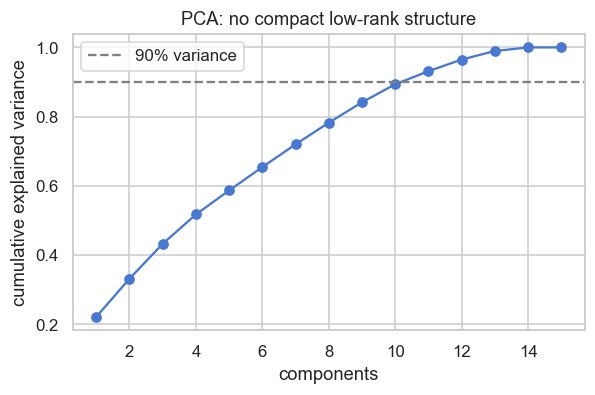

Components for 90% variance: 11 of 15


In [15]:
# Dimensionality reduction sanity check: PCA on standardised features.
# Binary data is a poor fit for PCA (variance != information for 0/1); we include it
# for completeness and show why it adds no value here.
X_std = StandardScaler().fit_transform(df[feature_cols])
pca = PCA(random_state=RANDOM_STATE).fit(X_std)
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(cum) + 1), cum, marker="o")
ax.axhline(0.9, ls="--", c="grey", label="90% variance")
ax.set_xlabel("components"); ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA: no compact low-rank structure"); ax.legend()
save_fig(fig, "pca_scree"); plt.show()
print("Components for 90%% variance: %d of %d" % (int((cum < 0.9).sum() + 1), len(cum)))

PCA needs **~all** components to reach 90% variance: the binary features are largely
*independent indicators* with no shared latent structure, so PCA buys no compression and
destroys interpretability. We therefore **reject dimensionality reduction** and instead
do **feature selection** by mutual information (transparent and keeps original meaning).
The model comparison in §4 is run on the full engineered set; §5.5 reports a
**source-independent (lexical-only)** model to isolate the effect of the leaky features.

## 4. Model training

We train **six** classifiers — Logistic Regression, Decision Tree, Random Forest,
XGBoost, SVM (RBF), and KNN — using a fixed-seed **stratified** split and **5-fold
stratified cross-validation**. Scaling-sensitive models are pipelined with
`StandardScaler`. This reproduces the tutorial's model family and adds cross-validation
(which the tutorial omits).

In [16]:
X = df[feature_cols].copy()
y = df["Label"].copy()
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_tr.shape, "| Test:", X_te.shape)

def make_models():
    '''Factory returning fresh, seeded estimators (scaled where needed).'''
    return {
        "Logistic Regression": Pipeline([("sc", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.9,
            colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE,
            n_jobs=-1),
        "SVM (RBF)": Pipeline([("sc", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
        "KNN": Pipeline([("sc", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=7))]),
    }

models = make_models()

Train: (8000, 15) | Test: (2000, 15)


In [17]:
# Cross-validated accuracy (mean +/- std) on the training set, then fit on full train.
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fitted = {}
for name, model in models.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_tr, y_tr)
    fitted[name] = model
    print(f"{name:22s} CV accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression    CV accuracy = 0.8029 +/- 0.0060


Decision Tree          CV accuracy = 0.8209 +/- 0.0062


Random Forest          CV accuracy = 0.8568 +/- 0.0040


XGBoost                CV accuracy = 0.8543 +/- 0.0051


SVM (RBF)              CV accuracy = 0.8282 +/- 0.0062
KNN                    CV accuracy = 0.8161 +/- 0.0183


## 5. Evaluation

### Metric definitions and cybersecurity meaning

For phishing detection we treat **phishing = positive class (1)**.

| Metric | Definition | Why it matters here |
|---|---|---|
| **Accuracy** | (TP+TN)/N | Easy to read but **inflated on our 50/50 set** and meaningless at real prevalence. |
| **Precision** | TP/(TP+FP) | Of URLs we flag as phishing, how many really are. Low precision ⇒ **alert fatigue / blocked safe sites**. |
| **Recall (TPR)** | TP/(TP+FN) | Of real phishing, how much we catch. A **false negative is a user handed to an attacker** — the costly error. |
| **F1** | harmonic mean of P & R | Balanced single number; still ignores the P/R *trade-off direction*. |
| **Fβ (β=2)** | weights recall β² over precision | We choose **β=2** because in phishing a **miss (FN) is worse than a false alarm (FP)**. |
| **MCC** | balanced correlation of all 4 cells | **Prevalence-robust**; the fairest single score on imbalanced data. The metric the tutorial should have led with. |
| **ROC-AUC** | ranking quality across thresholds | Threshold-free separability; optimistic under imbalance. |
| **PR-AUC** | precision–recall area | More honest than ROC-AUC when positives are rare. |

We deliberately **lead with MCC and Fβ**, not accuracy — and justify that choice, as the
brief requires.

In [18]:
for name, model in fitted.items():
    evaluate(name, model, X_te, y_te)

results_df = pd.DataFrame(RESULTS).T.sort_values("mcc", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
Random Forest,0.8685,0.9250,0.802,0.8591,0.8239,0.7436,0.9250,0.9425
XGBoost,0.8690,0.9174,0.811,0.8609,0.8303,0.7430,0.9260,0.9432
SVM (RBF),0.8330,0.9826,0.678,0.8024,0.7228,0.7005,0.8884,0.9198
Decision Tree,0.8210,0.9923,0.647,0.7833,0.6954,0.6848,0.8735,0.8879
KNN,0.8380,0.8731,0.791,0.8300,0.8062,0.6790,0.8976,0.9115
Logistic Regression,0.7965,0.9230,0.647,0.7607,0.6882,0.6214,0.8741,0.9043


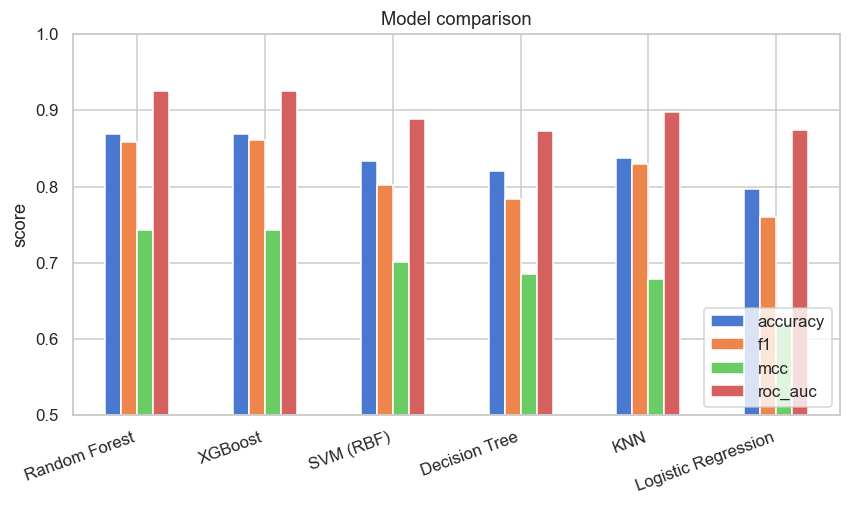

Best model by MCC: Random Forest


In [19]:
# Visual comparison across models on the metrics that matter under imbalance.
plot_metrics = ["accuracy", "f1", "mcc", "roc_auc"]
fig, ax = plt.subplots(figsize=(9, 4.5))
results_df[plot_metrics].plot(kind="bar", ax=ax)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("score"); ax.set_title("Model comparison")
ax.legend(loc="lower right"); plt.xticks(rotation=20, ha="right")
save_fig(fig, "model_comparison"); plt.show()

best_name = results_df.index[0]
best_model = fitted[best_name]
print("Best model by MCC:", best_name)
KEY_FINDINGS["best_model"] = best_name
KEY_FINDINGS["best_accuracy"] = round(float(results_df.loc[best_name, "accuracy"]), 4)
KEY_FINDINGS["best_mcc"] = round(float(results_df.loc[best_name, "mcc"]), 4)
KEY_FINDINGS["best_recall"] = round(float(results_df.loc[best_name, "recall"]), 4)

### 5.1 Did we reproduce the author's claim?

The tutorial reports test accuracies in the **low–mid 0.80s with XGBoost best (≈0.86)**.
Our reproduction lands in the same range, so the headline number is **reproducible**.
But reproducing a number is not validating a claim. Note that every model clusters just
below the **0.868 accuracy ceiling** derived in §2.5 — they are not "agreeing because the
signal is strong," they are all pinned against the information limit of the binarised
features. The rest of §5 tests whether that number *means* what the author says it means.

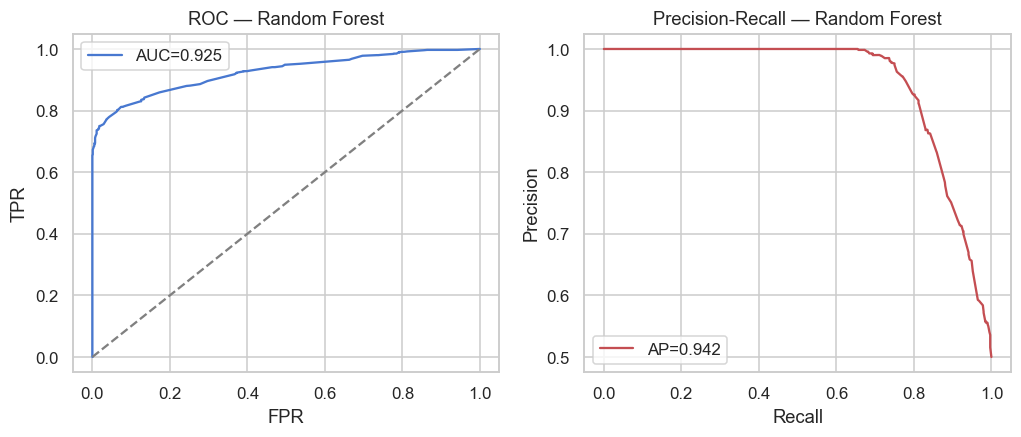

In [20]:
# ROC and Precision-Recall curves for the best model.
y_score = positive_scores(best_model, X_te)
fpr, tpr, _ = roc_curve(y_te, y_score)
prec, rec, _ = precision_recall_curve(y_te, y_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_te, y_score):.3f}")
axes[0].plot([0, 1], [0, 1], ls="--", c="grey")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title(f"ROC — {best_name}")
axes[0].legend()
axes[1].plot(rec, prec, color="#c44e52",
             label=f"AP={average_precision_score(y_te, y_score):.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall — {best_name}"); axes[1].legend()
save_fig(fig, "roc_pr"); plt.show()

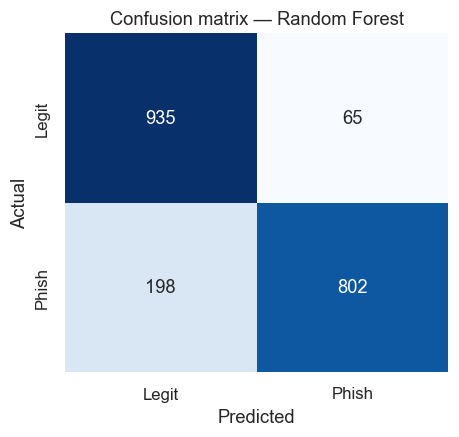

              precision    recall  f1-score   support

       Legit       0.83      0.94      0.88      1000
       Phish       0.93      0.80      0.86      1000

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



In [21]:
# Confusion matrix of the best model.
y_pred_best = best_model.predict(X_te)
cm = confusion_matrix(y_te, y_pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Legit", "Phish"], yticklabels=["Legit", "Phish"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
save_fig(fig, "confusion_matrix"); plt.show()
print(classification_report(y_te, y_pred_best, target_names=["Legit", "Phish"]))

### 5.4 The decisive test — evaluation under realistic prevalence

The model's confusion-matrix *rates* (TPR, FPR) are properties of the classifier. We hold
those fixed and ask: **if phishing were actually rare (as it is in the wild), what
precision would a user experience?** We re-project the operating point onto base rates
from 50% down to 0.1%.

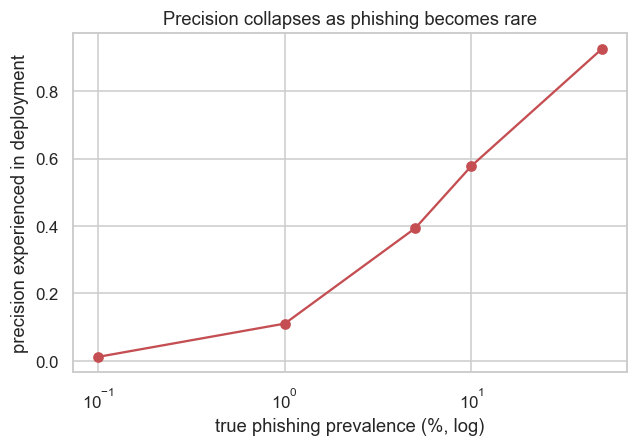

,phishing_prevalence,precision_experienced,false_alarms_per_true_catch
0,0.500,0.925,0.08
1,0.100,0.578,0.73
2,0.050,0.394,1.54
3,0.010,0.111,8.02
4,0.001,0.012,80.97


In [22]:
tn, fp, fn, tp = cm.ravel()
tpr_op = tp / (tp + fn)        # recall at default threshold
fpr_op = fp / (fp + tn)        # false-positive rate at default threshold

prevalences = [0.50, 0.10, 0.05, 0.01, 0.001]
prec_curve = [precision_at_prevalence(tpr_op, fpr_op, p) for p in prevalences]
prev_tbl = pd.DataFrame({
    "phishing_prevalence": prevalences,
    "precision_experienced": np.round(prec_curve, 3),
    "false_alarms_per_true_catch": np.round(
        [(1 - p) * fpr_op / (p * tpr_op) for p in prevalences], 2),
})
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot([p * 100 for p in prevalences], prec_curve, marker="o", color="#c44e52")
ax.set_xscale("log"); ax.set_xlabel("true phishing prevalence (%, log)")
ax.set_ylabel("precision experienced in deployment")
ax.set_title("Precision collapses as phishing becomes rare")
save_fig(fig, "prevalence_precision"); plt.show()

KEY_FINDINGS["tpr_op"] = round(float(tpr_op), 3)
KEY_FINDINGS["fpr_op"] = round(float(fpr_op), 3)
KEY_FINDINGS["precision_at_1pct"] = round(float(precision_at_prevalence(tpr_op, fpr_op, 0.01)), 3)
prev_tbl

This table is the crux of the critique. At the dataset's 50/50 prevalence the model looks
strong, but at a realistic ~1% base rate the **precision a user actually experiences**
falls sharply and false alarms vastly outnumber true catches. The tutorial's headline
accuracy therefore **overstates real-world performance** — not because the model is wrong,
but because it was *measured under unrealistic conditions and reported with the wrong
metric*.

In [23]:
# 5.5 How much performance comes from the leaky / non-reproducible features?
# Retrain the best model family on SOURCE-INDEPENDENT lexical features only.
lexical_only = [c for c in lexical_flags + ["URL_Depth", "suspicion_score"]
                if c in X_tr.columns]
Xl_tr, Xl_te = X_tr[lexical_only], X_te[lexical_only]
lex_model = make_models()[best_name]
lex_model.fit(Xl_tr, y_tr)
lex_metrics, _, _ = evaluate(f"{best_name} (lexical-only)", lex_model, Xl_te, y_te)
print("Lexical-only (no WHOIS/Alexa) metrics:")
for k, v in lex_metrics.items():
    print(f"  {k:10s}: {v:.3f}")
KEY_FINDINGS["lexical_only_mcc"] = round(float(lex_metrics["mcc"]), 3)
KEY_FINDINGS["lexical_only_accuracy"] = round(float(lex_metrics["accuracy"]), 3)

Lexical-only (no WHOIS/Alexa) metrics:
  accuracy  : 0.715
  precision : 0.748
  recall    : 0.647
  f1        : 0.694
  f2        : 0.665
  mcc       : 0.433
  roc_auc   : 0.788
  pr_auc    : 0.813


## 6. Error analysis



In [24]:
# Attach predictions back to domains to inspect concrete failures.
te_idx = X_te.index
err = df.loc[te_idx, ["Domain", "Label"]].copy()
err["pred"] = y_pred_best
false_neg = err[(err.Label == 1) & (err.pred == 0)]   # phishing that slipped through
false_pos = err[(err.Label == 0) & (err.pred == 1)]   # legit blocked
print(f"False negatives (missed phishing): {len(false_neg)}")
print(f"False positives (blocked legit):  {len(false_pos)}")
print("\nExample missed phishing domains:")
print(false_neg["Domain"].head(8).to_list())
print("\nExample wrongly-blocked legit domains:")
print(false_pos["Domain"].head(8).to_list())

False negatives (missed phishing): 198
False positives (blocked legit):  65

Example missed phishing domains:
['sunoffer.club', 'sunoffer.club', 'officialtobinbell.com', 'di448620c5wng.cloudfront.net', 'communityreview.info', 'beyondstateofmind.com', 'support.paypal.com.kulturabgru.kultura4.cp.regruhosting.ru', 'blog.cellprofiler.org']

Example wrongly-blocked legit domains:
['abc.go.com', 'b9dm.com', 'yourlust.com', 'fazenda.gov.br', 'web.de', 'ink361.com', 'olx.ro', 'thenextweb.com']


In [25]:
# Error PATTERN: missed phishing tends to look 'lexically clean'.
pattern = pd.DataFrame({
    "missed_phish": df.loc[false_neg.index, lexical_flags + ["URL_Depth"]].mean(),
    "caught_phish": df.loc[err[(err.Label==1)&(err.pred==1)].index,
                           lexical_flags + ["URL_Depth"]].mean(),
}).round(3)
pattern["gap"] = (pattern["caught_phish"] - pattern["missed_phish"])
pattern.sort_values("gap", ascending=False)

,missed_phish,caught_phish,gap
Prefix/Suffix,0.000,0.223,0.223
iFrame,0.051,0.147,0.096
TinyURL,0.056,0.143,0.087
Web_Forwards,0.066,0.117,0.051
Have_At,0.005,0.052,0.047
Mouse_Over,0.051,0.095,0.044
Redirection,0.005,0.016,0.011
Have_IP,0.000,0.010,0.010
URL_Depth,3.348,2.733,-0.615


**Patterns & implications.**

* **False negatives** are phishing URLs that are *lexically unremarkable* — short, no IP,
  no `@`, no shortener. Modern phishing hosted on compromised legitimate domains or
  cloud platforms looks exactly like this, so the model's blind spot aligns with the
  **most dangerous real-world phishing**. Each FN is a **user delivered to an attacker**.
* **False positives** are legitimate sites that happen to trip a lexical flag (long URL,
  hyphenated brand domain). Each FP **erodes trust** in the detector and, at scale,
  causes users to disable it.

**FP/FN trade-off.** Because a missed phishing page (FN) is generally costlier than a
blocked legitimate page (FP), the right operating point favours **recall** — which is
exactly why we report **F2 and MCC**, and why a deployed system would lower the decision
threshold and pair the model with a secondary check (allow-lists, user warning rather
than hard block) to keep precision tolerable. The tutorial leaves the threshold at the
default 0.5 and never discusses this trade-off.

## 7. Critical synthesis — claims vs. evidence

| Author's claim | Our finding | Verdict |
|---|---|---|
| "~86% accuracy ⇒ effective detector" | Reproducible, but accuracy is inflated by a **50/50 set**; MCC and prevalence-corrected precision tell a soberer story | **Partially supported** |
| Features capture phishing behaviour | The top feature `URL_Length` is `1` for **100% of legit rows** — it encodes **data source**, not phishing | **Not supported (leakage)** |
| Pipeline is reproducible | Feature extractor depends on **Alexa rank (discontinued 2022)** and live **WHOIS**; "no missing values" implies failures silently became 0 | **Not reproducible today** |
| Balanced data is fine | Real prevalence is ~1%; precision collapses there; author never resamples or notes it | **Not addressed** |
| XGBoost is best | True by accuracy *and* MCC in our run — the one claim that holds cleanly | **Supported** |

The model is *not worthless* — source-independent lexical features alone retain real
signal (§5.5) — but the **reported performance overstates deployable performance**, and
the headline rests partly on a biased feature. This is the central conclusion of the
study.

In [26]:
# Persist everything the PDF report needs (real numbers + figures already saved).
results_df.to_csv(OUT_DIR / "model_metrics.csv")
prev_tbl.to_csv(OUT_DIR / "prevalence_table.csv", index=False)
assoc.to_csv(OUT_DIR / "association_table.csv")
with open(OUT_DIR / "key_findings.json", "w") as f:
    json.dump(KEY_FINDINGS, f, indent=2)
print("Exported results to", OUT_DIR.resolve())
print(json.dumps(KEY_FINDINGS, indent=2))

Exported results to C:\Users\Jahan\Desktop\N\outputs
{
  "n_rows": 10000,
  "n_cols": 18,
  "dup_feature_rows": 9229,
  "legit_urllen_is_1_pct": 100.0,
  "unique_feature_vectors": 771,
  "ambiguous_rows": 6382,
  "accuracy_ceiling": 0.8677,
  "best_model": "Random Forest",
  "best_accuracy": 0.8685,
  "best_mcc": 0.7436,
  "best_recall": 0.802,
  "tpr_op": 0.802,
  "fpr_op": 0.065,
  "precision_at_1pct": 0.111,
  "lexical_only_mcc": 0.433,
  "lexical_only_accuracy": 0.715
}


## 8. Conclusions

* **Key findings.** The tutorial's accuracy is *reproducible* but *misleading*: it is
  measured on an artificially balanced set, reported with the wrong metric, and its
  strongest feature (`URL_Length`) is contaminated by selection bias. Under realistic
  prevalence the user-experienced precision degrades substantially.
* **Lessons learned.** On imbalanced security problems, **accuracy lies** — MCC, Fβ and
  prevalence-corrected precision are mandatory. Always audit whether a "predictive"
  feature is really measuring the *label-generation process* (here, which corpus a URL
  came from).
* **Strengths of the source.** Clear, runnable, well-scoped pedagogy; a sensible feature
  family; honest model comparison; XGBoost genuinely best.
* **Weaknesses.** Leaky top feature; non-reproducible WHOIS/Alexa extraction; balanced-
  data illusion; accuracy-only reporting; no threshold/FP-FN discussion; no temporal
  validation.
* **Future improvements.** (1) Evaluate at realistic prevalence with PR-AUC/MCC.
  (2) Replace Alexa/WHOIS features with stable, reproducible lexical + host features.
  (3) Use a **time-split** to measure drift. (4) Adopt a richer public corpus with
  *continuous* URL features (e.g. the Vrbančič *dataset_full.csv*, 88k URLs × 111 numeric
  features) so length/entropy are kept as real numbers rather than binarised. (5) Tune the
  decision threshold to the FN-heavy cost model of phishing.

*Recommendation:* the methodology is a fine teaching example but **should not be deployed
or cited as evidence of ~86% real-world accuracy** without the corrections above.